<a href="https://colab.research.google.com/github/david132313/DL-ML_practice/blob/main/Fall2025_473_Lab13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recitation: K-Means

In this recitation, you will cover the k-means algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

np.random.seed(0)

# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (5, 4)
plt.rcParams["axes.grid"] = True

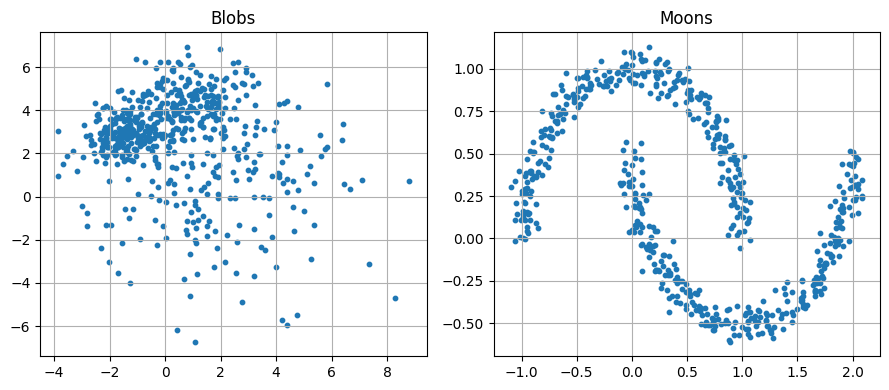

In [2]:
X_blobs, y_blobs_true = make_blobs(
    n_samples=600,
    centers=3,
    cluster_std=[1.0, 2.5, 0.7],
    random_state=0
)

X_moons, y_moons_true = make_moons(
    n_samples=600,
    noise=0.06,
    random_state=0
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=10)
axes[0].set_title("Blobs")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], s=10)
axes[1].set_title("Moons")
plt.tight_layout()
plt.show()

# 1. K-Means: Implementation Practice

### 1.1 Discussion! Concept Check

Discuss with your group and answer in your own words:

1. What objective does k-means minimize?
2. What are the two steps repeated in the standard k-means algorithm?
3. Why can different random initializations give different final solutions?


*TODO: Your response here.*

### 1.2 Implement One K-Means Iteration

We will now implement the key operations for k-means on 2D data:

- **Assignment step:** assign each point to its nearest centroid.
- **Update step:** recompute each centroid as the mean of points assigned to that cluster.

You will complete two short functions:

- `assign_points_to_clusters(X, centroids)`
- `update_centroids(X, labels, k)`

In [5]:
def assign_points_to_clusters(X, centroids):
    """
    X: (n_samples, n_features)
    centroids: (k, n_features)

    Return:
        labels: (n_samples,) with values in {0, ..., k-1}
    """
    # Compute squared Euclidean distance from each point to each centroid.
    # X[:, None, :]       -> (n_samples, 1, n_features)
    # centroids[None, :, :] -> (1, k, n_features)
    # diff                 -> (n_samples, k, n_features)
    diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    dists_sq = np.sum(diff ** 2, axis=2)        # (n_samples, k)

    # For each sample, pick the index of the closest centroid
    labels = np.argmin(dists_sq, axis=1)        # (n_samples,)
    return labels


def update_centroids(X, labels, k):
    """
    X: (n_samples, n_features)
    labels: (n_samples,) cluster assignments
    k: number of clusters

    Return:
        new_centroids: (k, n_features)
    """
    n_samples, n_features = X.shape
    new_centroids = np.zeros((k, n_features))

    for j in range(k):
        mask = (labels == j)
        if np.any(mask):
            # Mean of all points assigned to cluster j
            new_centroids[j] = X[mask].mean(axis=0)
        else:
            # (Optional) handle empty cluster: reinitialize to random point
            new_centroids[j] = X[np.random.randint(n_samples)]

    return new_centroids


def kmeans_step(X, centroids):
    """Perform one full k-means iteration: assignment + centroid update."""
    labels = assign_points_to_clusters(X, centroids)
    new_centroids = update_centroids(X, labels, centroids.shape[0])
    return labels, new_centroids


### 1.3 Run K-Means on the Blob Dataset

Now use your implementation on `X_blobs` with `k = 3`:

1. Initialize centroids by choosing three random points.
2. Run about 10 iterations of `kmeans_step`.
3. Plot final clusters and centroids.

Focus on getting something reasonable that visually separates the three blobs.

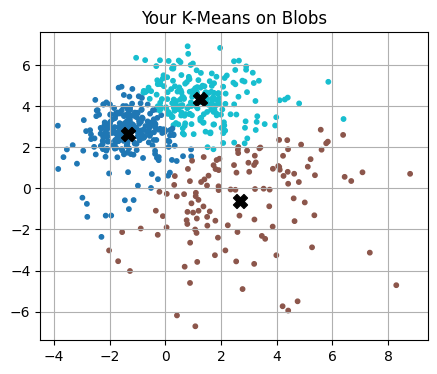

In [6]:
k = 3
X = X_blobs

# Initialize centroids by sampling k random points from X
indices = np.random.choice(len(X), size=k, replace=False)
centroids = X[indices]

for step in range(10):
    labels, centroids = kmeans_step(X, centroids)

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap="tab10")
ax.scatter(centroids[:, 0], centroids[:, 1], c="black", s=100, marker="X")
ax.set_title("Your K-Means on Blobs")
plt.show()

### 1.4 Quick Comparison with scikit-learn (5 minutes)

Now compare with `sklearn.cluster.KMeans`:

1. Fit `KMeans(n_clusters=3, random_state=0)` on `X_blobs`.
2. Plot the resulting labels and centroids.
3. Print the reported **inertia_** (sum of squared distances to nearest centroid).

You do not need to perfectly match scikit-learn's result. The goal is to see a similar structure.

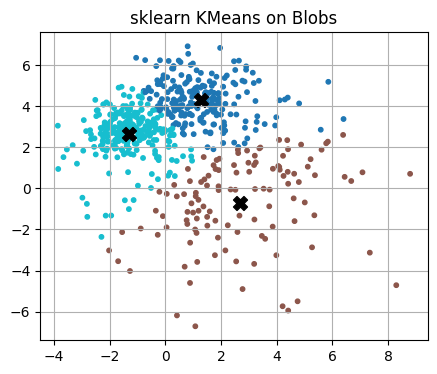

KMeans inertia on blobs: 2101.9803252193747


In [7]:
km = KMeans(n_clusters=3, random_state=0, n_init=10)
km.fit(X_blobs)
km_labels = km.labels_
km_centroids = km.cluster_centers_

fig, ax = plt.subplots()
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=km_labels, s=10, cmap="tab10")
ax.scatter(km_centroids[:, 0], km_centroids[:, 1], c="black", s=100, marker="X")
ax.set_title("sklearn KMeans on Blobs")
plt.show()

print("KMeans inertia on blobs:", km.inertia_)

###1.5 Discussion!

Discuss with your group and answer in your own words:

1. Why can different random initializations lead to different clusterings?
2. If the algorithm is run multiple times with different seeds, how could one choose a "best" run?

*TODO: Your response here.*


In k-means, the algorithm starts from randomly chosen initial centroids and then greedily improves the objective (within-cluster squared distance). The objective is non-convex, so there are many local minima. Depending on where we start, the algorithm can get stuck in different local minima and therefore converge to different final centroids and different cluster assignments.

If the algorithm is run multiple times with different seeds, how could one choose a “best” run?
A common approach is to run k-means several times with different random initializations and then pick the run with the lowest objective value (smallest total within-cluster sum of squared distances / inertia). More generally, we could compare runs using a clustering quality metric such as silhouette score and choose the run with the best score.


# 2. Open-Ended Questions & Discussion

In this section, you will reflect on the materials you have covered in class so far and record any questions that remain about the material. First consider the most recent material, then consider earlier material.

Record:


*  2 things that you have learned or you feel that you better understand from this recitation.
*   2 questions that you still have about the material.

Feel free to share with your group and discuss!



*TODO: Your response here.*
I understand the k-means update loop much better: alternate between assigning each point to its nearest centroid and recomputing each centroid as the mean of the points assigned to it.

I learned how random initialization and the choice of k strongly affect the final clustering, and that k-means works well for roughly spherical “blob” clusters but struggles on non-convex shapes like the moons dataset.

Two questions I still have about the material

In practice, what are the most reliable methods to choose the number of clusters k (e.g., elbow method, silhouette score, information criteria), and when should we prefer one method over another?

How does k-means compare to more flexible methods like Gaussian Mixture Models or spectral clustering when data has overlapping or non-spherical clusters, and how do we decide which clustering algorithm to use on a real dataset?